# 纯黑箱模型能否击败经典提前还款方程？

本交互式实验是 **第 9 章：房贷建模中的人工智能与机器学习** 核心实务探讨以及配套脚本 `ml_vs_classical_rmse.py` 的实验呈现。所有底层评测与数据流逻辑均直接复用该脚本，确保 Notebook 中的回测数值与正文印刷数据完全一致。

- **贷款样本数据**：房利美在 2000 年第一季度（2000Q1）收购的约 12,700 笔单户住宅贷款（取自 Single-Family Loan Performance 前 120 MB 真实数据流），并逐月完整追踪其穿越 2001–2003 年历史性再融资大潮的全过程。
- **市场利率序列**：房地美公布的 30 年期固定利率房贷每周调查均值（按月聚合）。单笔贷款当月的再融资激励即为其契约利率减去上月市场参考利率。

首次运行需要访问房利美与房地美公开数据接口，下载并自动缓存在 `~/.cache/mortgagekit` 目录下。请使用 `Python (usao)` 环境内核运行。

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Works whether the notebook runs from its own folder or from the repo root.
here = Path.cwd()
if not (here / "ml_vs_classical_rmse.py").exists():
    here = here / "chapter9-ai-ml-modeling" / "code"
sys.path.insert(0, str(here))

import ml_vs_classical_rmse as exp
from mortgagekit.figstyle import BORROWER, DEALER, LENDER, SERVICER, SLATE, configure_book_style

configure_book_style()
%matplotlib inline
COLORS = {"S-curve, incentive only": SERVICER, "Multi-factor equation": LENDER, "Gradient-boosted tree": DEALER}
# 配置中文无衬线字体与负号正常显示
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False


## 贷款级与月度面板构建

每笔贷款每个存续月份生成一行观测。预测目标为二元标签：若贷款在当月自愿还清结清（零余额代码 01），则标签为 1，否则为 0。违约与清收等信用终止属于竞争风险（Competing Risk），在预处理中直接剔除而非计入正常提前还款。

12,732 loans, 473,145 loan-months, 12,463 voluntary payoffs


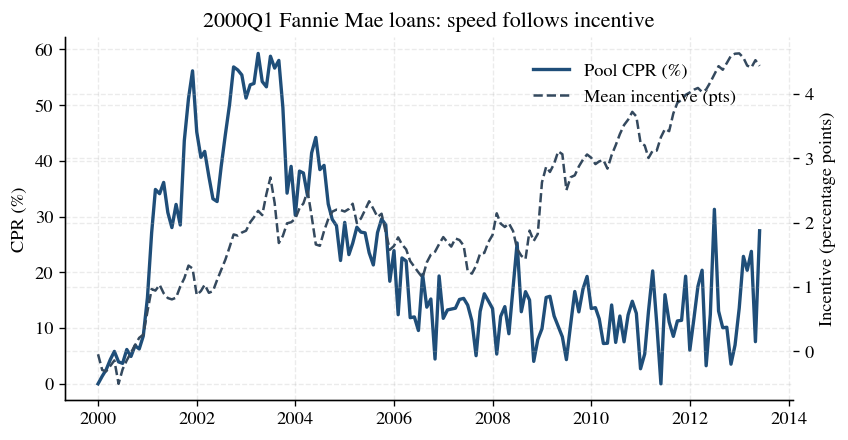

In [2]:
x, y, loans, periods = exp.build_panel()
print(f"{len(np.unique(loans)):,} loans, {len(y):,} loan-months, {int(y.sum()):,} voluntary payoffs")

# Pool CPR of the whole sample by month, with the refinance incentive it faced.
months = np.unique(periods)
alive = np.array([(periods == m).sum() for m in months])
pool_cpr = np.array([exp.cpr(y[periods == m].mean()) for m in months]) * 100
pool_inc = np.array([x[periods == m, exp.INCENTIVE].mean() for m in months])
keep = alive >= exp.MIN_LOANS_PER_MONTH
dates = np.array([np.datetime64(f"{m // 100}-{m % 100:02d}") for m in months])

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(dates[keep], pool_cpr[keep], color=BORROWER, lw=2, label="Pool CPR (%)")
ax.set_ylabel("CPR (%)")
ax2 = ax.twinx()
ax2.plot(dates[keep], pool_inc[keep], color=SLATE, lw=1.5, ls="--", label="Mean incentive (pts)")
ax2.set_ylabel("Incentive (percentage points)")
ax.set_title("2000Q1 Fannie Mae loans: speed follows incentive")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88), frameon=False)
fig.tight_layout()

## 三个模型在留出测试集贷款上的评测

我们采用标准的历史切分法则：按贷款个体划分并留出 30% 作为独立测试集，确保同一笔贷款绝不会同时出现在训练集和测试集两侧。

1. **单因子 S 曲线方程（仅利差激励）**：经典的单一逻辑斯蒂公式；
2. **多因子经典方程**：S 曲线乘以账龄上升段、耗竭乘数以及季节性项，所有结构性因子均由人工显式定义；
3. **梯度提升决策树 (Gradient-Boosted Tree)**：输入上述所有因子外加信用分 FICO、LTV、DTI、贷款金额、用途、渠道及自住状态，完全不预设任何函数形状。

In [3]:
rng = np.random.default_rng(exp.SEED)
unique_loans = np.unique(loans)
held_out = np.isin(loans, rng.choice(unique_loans, int(exp.TEST_SHARE * len(unique_loans)), replace=False))

models = exp.fit_all(x[~held_out], y[~held_out])
exp.report("Held-out loans, same calendar period", models, x[held_out], y[held_out], periods[held_out])


Held-out loans, same calendar period
  model                       loan-month RMSE  monthly CPR RMSE
  S-curve, incentive only             0.15861         11.42 CPR
  Multi-factor equation               0.15800          8.19 CPR


  Gradient-boosted tree               0.15718          5.29 CPR
  (70 months with at least 300 held-out loans alive)


若按单笔贷款月度逐一打分，三个模型的表现几乎难分伯仲：每个“贷款-月份”本质上都像一枚抛掷的硬币，其固有的二元微观噪声会淹没任何模型的微小优势。然而，若将预测聚合为测试集资产池的月度 CPR（这正是交易台实际交易与对冲的核心指标），模型间的差距将瞬间拉开。下方图表揭示了这种差距的来源。

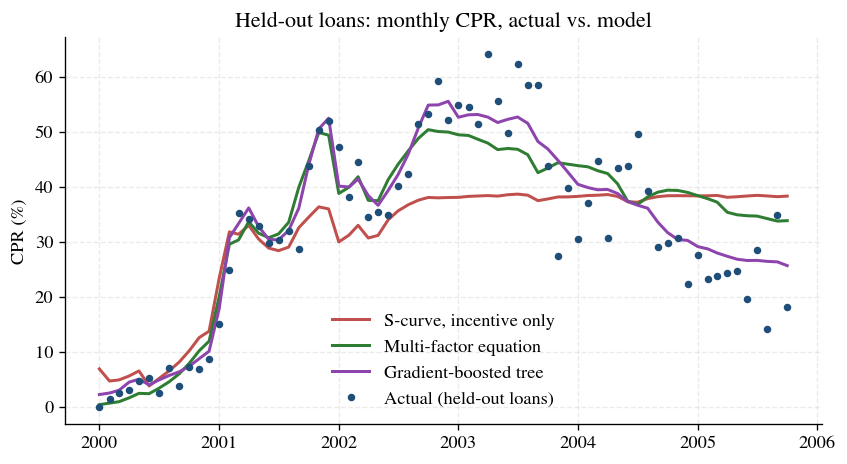

In [4]:
def monthly_cpr(predicted, y_, p_):
    ms = [m for m in np.unique(p_) if (p_ == m).sum() >= exp.MIN_LOANS_PER_MONTH]
    d = np.array([np.datetime64(f"{m // 100}-{m % 100:02d}") for m in ms])
    actual = np.array([exp.cpr(y_[p_ == m].mean()) for m in ms]) * 100
    model = np.array([exp.cpr(predicted[p_ == m].mean()) for m in ms]) * 100
    return d, actual, model

fig, ax = plt.subplots(figsize=(7.2, 4.0))
for name, predict in models.items():
    d, actual, model = monthly_cpr(predict(x[held_out]), y[held_out], periods[held_out])
    ax.plot(d, model, color=COLORS[name], lw=1.8, label=name)
ax.plot(d, actual, color=BORROWER, lw=0, marker="o", ms=3.5, label="Actual (held-out loans)")
ax.set_ylabel("CPR (%)")
ax.set_title("Held-out loans: monthly CPR, actual vs. model")
ax.legend(frameon=False)
fig.tight_layout()

## 误差指标未能察觉的隐患：曲线的内在形状

均方根误差（RMSE）只会奖励与历史真实数值的机械吻合。它从来不关心当利率变动时，预测结果是否沿着正确的经济学方向演进。将所有留出测试集贷款的再融资利差同时提升 25 bp：一个符合常理的健康模型绝不能预测出*更低*的提前还款率。

In [5]:
tree = models["Gradient-boosted tree"]
bumped = x[held_out].copy()
bumped[:, exp.INCENTIVE] += 0.25
wrong_way = np.mean(tree(bumped) < tree(x[held_out]) - 1e-12)
print(f"+25bp of incentive lowers the tree's forecast on {wrong_way:.0%} of held-out loan-months")

+25bp of incentive lowers the tree's forecast on 12% of held-out loan-months


在网格上全面扫描再融资利差激励，并绘制各模型预测的 CPR 响应曲线。左图展示了在 5,000 笔贷款上的平均响应；右图展示了单笔贷款的微观响应（这正是交易台在执行微扰敏感性重定价时所依赖的核心行为）。经典公式在数学构造上天生平滑且单调递增；而决策树则呈现出阶梯状切分，甚至部分阶梯在更大利差下出现了反常向下的断崖。

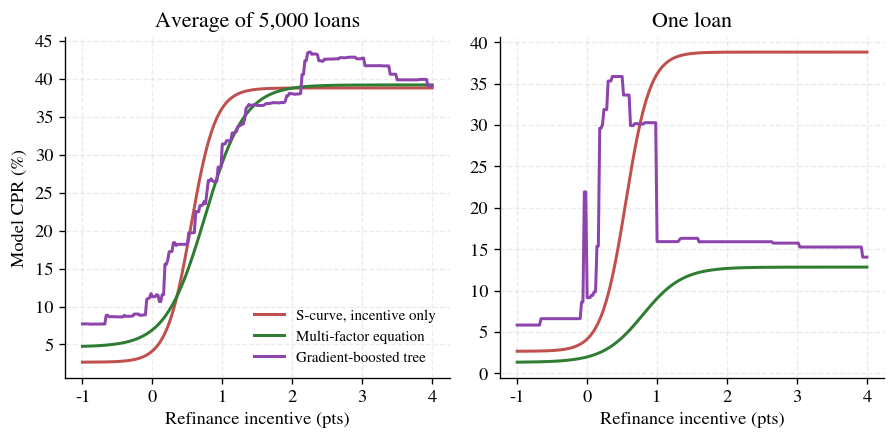

In [6]:
grid = np.arange(-1.0, 4.01, 0.02)
sample = x[held_out][np.random.default_rng(1).choice(held_out.sum(), 5000, replace=False)]
one_loan = sample[:1]

def response(predict, rows):
    out = []
    for g in grid:
        z = rows.copy()
        z[:, exp.INCENTIVE] = g
        out.append(exp.cpr(predict(z).mean()) * 100)
    return np.array(out)

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8), sharey=False)
for ax, rows, title in [(axes[0], sample, "Average of 5,000 loans"), (axes[1], one_loan, "One loan")]:
    for name, predict in models.items():
        ax.plot(grid, response(predict, rows), color=COLORS[name], lw=1.8, label=name)
    ax.set_xlabel("Refinance incentive (pts)")
    ax.set_title(title)
axes[0].set_ylabel("Model CPR (%)")
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()

## 更严苛的考验：跨越时间维度的体制外推

我们在 2000–2001 年的数据上拟合模型，随后直接要求其预测 2002–2003 年爆发的极端再融资浪潮——在那段时期，再融资利差激励远超训练年份所见过的任何历史极值。


Out of time: fit on 2000-2001, forecast 2002-2003
  model                       loan-month RMSE  monthly CPR RMSE
  S-curve, incentive only             0.22150          7.65 CPR
  Multi-factor equation               0.22143          7.24 CPR
  Gradient-boosted tree               0.22126          9.03 CPR
  (24 months with at least 300 held-out loans alive)


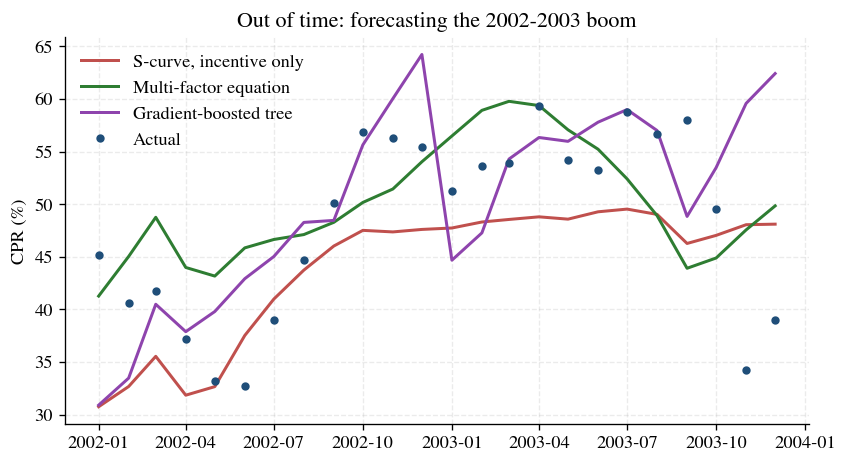

In [7]:
train = periods < 200201
test = (periods >= 200201) & (periods < 200401)
models_oot = exp.fit_all(x[train], y[train])
exp.report("Out of time: fit on 2000-2001, forecast 2002-2003", models_oot, x[test], y[test], periods[test])

fig, ax = plt.subplots(figsize=(7.2, 4.0))
for name, predict in models_oot.items():
    d, actual, model = monthly_cpr(predict(x[test]), y[test], periods[test])
    ax.plot(d, model, color=COLORS[name], lw=1.8, label=name)
ax.plot(d, actual, color=BORROWER, lw=0, marker="o", ms=4, label="Actual")
ax.set_ylabel("CPR (%)")
ax.set_title("Out of time: forecasting the 2002-2003 boom")
ax.legend(frameon=False)
fig.tight_layout()

## 核心实务结论

- 在相同时间区间的留出贷款集上，梯度提升决策树大幅击败了两套经典方程，并在资产池级 CPR 层面展现出压倒性的拟合优势。这证实了机器学习强大的特征挖掘能力；
- 然而，同一棵决策树在相当比例的贷款-月份上，竟然预测出“再融资利差越大、提前还款反而越慢”的荒谬走势。RMSE 指标对此完全盲目，而交易台的对冲比率却会被其彻底带偏；
- 当被要求外推预测一个全新的利率体制时，决策树迅速丧失了领先优势。更低的历史 RMSE 绝不能证明模型能在下一轮再融资风暴中幸免于难。

这也正是第 9 章后续推导混合集成残差架构的核心根基：**将经济学方程作为坚不可摧的单调性骨架，而让机器学习算法在其之上学习受限且安全的微观残差！**